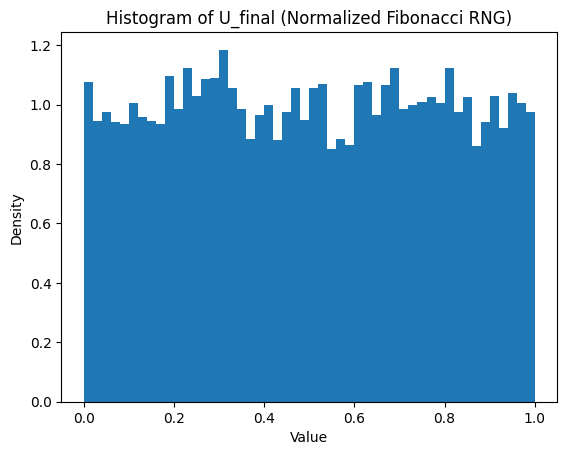

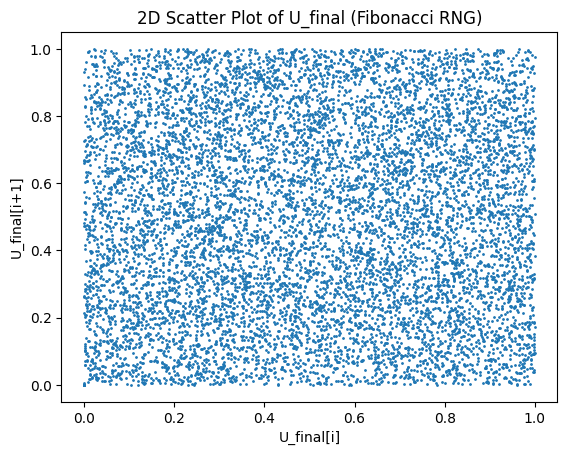

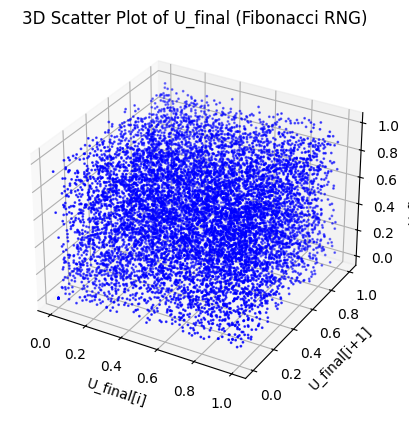

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters for the Fibonacci RNG
M = 244944  # Modulus
j, k = 5, 17  # Indices for the recurrence relation

# Initialize arrays
n_samples = 10**4
U = np.zeros(n_samples, dtype=np.int64)  # Raw integer values
U_final = np.zeros(n_samples, dtype=np.float64)  # Normalized [0, 1)

# Seed the first k values with LCG
a, b = 1597, 51749  # LCG parameters
U[0:k] = [12345]  # Seed value for LCG
for i in range(1, k):  # Generate initial k values using LCG
    U[i] = (U[i-1] * a + b) % M

# Fibonacci RNG computation
for i in range(k, n_samples):
    U[i] = (U[i-j] + U[i-k]) % M  # Fibonacci recurrence
    U_final[i] = U[i] / M  # Normalize to [0, 1)

# Plot the results
plt.figure(1)
plt.hist(U_final, bins=50, density=True)
plt.title('Histogram of U_final (Normalized Fibonacci RNG)')
plt.xlabel('Value')
plt.ylabel('Density')

plt.figure(2)
plt.scatter(U_final[:-1], U_final[1:], s=1)
plt.title('2D Scatter Plot of U_final (Fibonacci RNG)')
plt.xlabel('U_final[i]')
plt.ylabel('U_final[i+1]')

fig = plt.figure(3)  # Create a new figure
ax = fig.add_subplot(111, projection='3d')  # Add a 3D subplot
ax.scatter(U_final[:-2], U_final[1:-1], U_final[2:], c='b', marker='o', s=1)
ax.set_title('3D Scatter Plot of U_final (Fibonacci RNG)')
ax.set_xlabel('U_final[i]')
ax.set_ylabel('U_final[i+1]')
ax.set_zlabel('U_final[i+2]')

plt.show()